## Definition

In [71]:
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import h5py
from tqdm import tqdm
import tifffile

from psf_toolbox import psf_high_NA_2D, render_psf_emitters, scaled_psf2

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

cwl = 580 #nm
au = 0.61*cwl/1.4 #airy unit in nm


In [72]:
def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    img = (img - np.min(img))
    img = img/np.sum(img)
    return img


## Step 1 - Abberation-free star

In [76]:
xy = np.array([(25,25),(10,10),(40,40)])

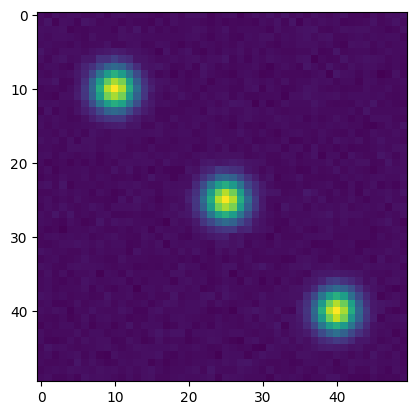

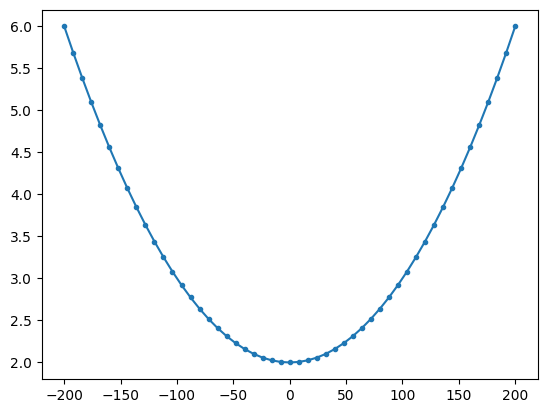

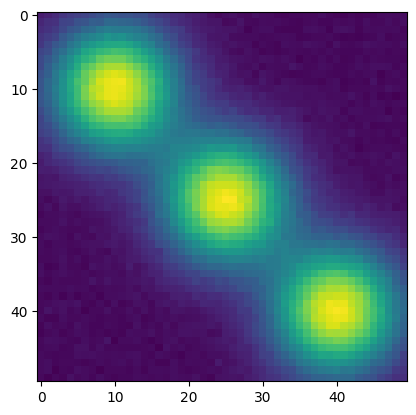

In [78]:
xyi = np.zeros((len(xy),3))
xyi[:,2] = 100
xyi[:,0:2] = xy
plt.imshow(generate_image(xyi, 3, 1, 2,  50, 50))
plt.show()

zs = np.linspace(-200,200,51)
psfw = 2 + 0.0001*zs**2
plt.plot(zs, psfw, ".-")
plt.show()

ims = np.array([generate_image(xyi, 3, 1, w,  50, 50) for w in psfw] )
ims /= np.max(ims)
plt.imshow(ims[0,:,:])
plt.show()

In [80]:
ims_cnts = np.clip(ims*65535, 0, 65535).astype(np.uint16)

## Step 2 - generate z-calibration data, save as tiff


In [81]:
from tifffile import TiffWriter

with TiffWriter('z_calib_like_gauss.tiff') as writer:
    writer.write(ims_cnts)
print('done')

done
